## Proyek Klasifikasi *Time Series* (CRISP-DM Tahap 1)

Dataset **Strawberry** yang dipilih berasal dari domain klasifikasi *time series* dan sangat relevan dengan topik yang dibahas dalam jurnal yang Anda unggah: "**Use of Fourier Transform Infrared Spectroscopy and Partial Least Squares Regression for the Detection of Adulteration of Strawberry Purées**".

Berikut adalah penjelasan rinci untuk langkah-langkah awal proyek Anda:

### 1. Memahami Bisnis/Konteks Proyek (Tujuan Analisis)

Ini adalah langkah untuk menentukan mengapa proyek ini dilakukan dan apa manfaatnya.

* **Latar Belakang/Konteks Masalah:**
    * **Isu Bisnis:** Adanya masalah pemalsuan (*adulteration*) dalam produk makanan, khususnya pada bubur (*purée*) buah-buahan seperti stroberi, karena buah-buahan tertentu memiliki harga premium. Pemalsuan ini sulit dideteksi setelah dicampur.
    * **Tantangan:** Metode pengujian kualitas konvensional (seperti HPLC atau TLC) cenderung lambat dan mahal, sehingga kurang ideal untuk pengujian rutin dalam industri.
    * **Solusi yang Ditawarkan Jurnal:** Menggunakan teknik spektroskopi inframerah transformasi Fourier (FT-IR) yang cepat dan dapat mendeteksi berbagai pemalsu, dikombinasikan dengan teknik kemometrik seperti **Partial Least Squares (PLS) Regression**.

* **Tujuan Proyek Utama (Berdasarkan Jurnal):**
    > **Tujuan utama adalah untuk mengembangkan metode yang cepat dan rutin untuk mendeteksi pemalsuan dalam bubur stroberi.** Metode ini harus mampu membedakan spektrum bubur stroberi murni dari spektrum sampel yang sudah dipalsukan atau buah lain.

* **Tujuan Klasifikasi Anda (Berdasarkan Tugas UAS):**
    * **Tujuan Teknis:** Membuat model klasifikasi *time series* (kemungkinan menggunakan spektrum FT-IR yang diinterpretasikan sebagai data *time series*) untuk secara otomatis mengklasifikasikan sampel sebagai:
        1.  **Stroberi Murni** (Kelas Positif)
        2.  **Bukan Stroberi** (Kelas Negatif, termasuk sampel teradulterasi/dipalsukan dan buah lain).

### 2. Memahami Data (Eksplorasi Data / EDA)

Ini adalah langkah untuk memahami jenis data, strukturnya, dan bagaimana data tersebut diperoleh.

#### A. Sumber dan Jenis Data

* **Sumber Data (Asli Jurnal):** Spektra inframerah tengah (*mid-IR spectra*) dari total 983 bubur buah digunakan untuk membangun dan menguji model PLS35, 63].
* **Dataset Anda (Strawberry):** Data ini adalah representasi digital dari spektrum FT-IR.
    * **Jenis Data:** *Time Series* (seri waktu) atau lebih tepatnya data spektra. Setiap "titik waktu" pada spektrum sebenarnya adalah titik data dalam domain panjang gelombang/bilangan gelombang (misalnya, rentang $899-1802 \text{ cm}^{-1}$ ).
    * **Struktur Data:** Data spektrum pada dasarnya adalah urutan numerik (seperti *time series*), di mana setiap urutan mewakili satu sampel bubur buah.

#### B. Tahapan Perolehan Data Spektra (Jurnal)

1.  **Pengumpulan Sampel:** Bubur buah disiapkan di laboratorium dari buah utuh (segar atau beku-cair) yang dipanen antara tahun 1993 dan 1995 untuk memastikan keasliannya.
2.  **Pembuatan Sampel Adulterasi:** Campuran dibuat dengan menambahkan bahan pemalsu seperti apel, prem, larutan gula (glukosa/sukrosa), jus anggur merah, dan *rhubarb compote* ke bubur stroberi murni.
3.  **Pengambilan Spektra FT-IR:** Spektra inframerah tengah dikumpulkan menggunakan spektrometer FT-IR.
4.  **Pra-pemrosesan Data Spektra:**
    * Rentang spektral dipotong/dibatasi (misalnya $899-1802 \text{ cm}^{-1}$).
    * Koreksi garis dasar (*baseline correction*) diterapkan.
    * Spektra **dinormalisasi** berdasarkan area spektral terintegrasi.
    * Ini menghasilkan data matriks **X** (spektra) dan vektor **y** (variabel boneka/dummy yang mewakili kelas).

#### C. Variabel dan Pemetaan Kelas (Variabel Dummy)

* **Variabel Independen (X):** Data spektrum (*area-normalised absorbance*) yang memiliki dimensi $n \times d$, di mana $n$ adalah jumlah sampel dan $d$ adalah jumlah titik data spektral (dalam jurnal, $d=235$).
* **Variabel Dependen (y) / Kelas:**
    * Dibuat vektor variabel *dummy* biner.
    * **Kelas 1 (Stroberi Murni):** Diberi kode **1**.
    * **Kelas 2 (Non-Stroberi):** Diberi kode **2** (mencakup sampel yang dipalsukan dan buah-buahan lain).

### 3. Pemodelan (Model Klasifikasi Jurnal)

Meskipun model Anda mungkin berbeda, jurnal memberikan kerangka kerja yang kuat untuk tugas Anda:

* **Metode Utama:** **Partial Least Squares (PLS) Regression** ke variabel *dummy*.
* **Cara Kerja Model PLS:**
    1.  PLS menghitung serangkaian beban PLS (*PLS loadings*) dari matriks data spektrum (X) dan kelas (y).
    2.  Spektra diproyeksikan ke beban ini untuk mendapatkan Skor PLS (*PLS Scores*) $\left(Z_{r}=X W_{r}\right)$. Ini adalah langkah reduksi dimensi penting.
    3.  Regresi linier berganda kemudian dilakukan dari variabel kelas (**y**) ke Skor PLS (**Z**), menghasilkan koefisien regresi.
    4.  Model ini kemudian digunakan untuk **memprediksi** nilai $\hat{y}$ untuk sampel baru.

### 4. Kriteria Klasifikasi (Hasil Model)

* **Penerimaan Sampel:** Sampel dianggap sebagai **Stroberi Murni** jika nilai $\hat{y}$ yang diprediksi jatuh dalam batas interval kepercayaan 95% di sekitar rata-rata prediksi untuk sampel stroberi murni (dalam jurnal, batasnya adalah 0,50 dan 1,20),.
* **Penolakan Sampel:** Sampel dianggap **Non-Stroberi** jika $\hat{y}$ berada di luar batas interval kepercayaan tersebut.

---

## 🎯 Rangkuman Tahap Awal Anda

Anda telah menyelesaikan tahap awal CRISP-DM dengan baik:

| Tahap CRISP-DM | Deskripsi |
| :--- | :--- |
| **Memahami Bisnis** | Tujuannya adalah membangun model klasifikasi *time series* (spektra) untuk mendeteksi **pemalsuan (adulterasi) bubur stroberi** secara cepat, membedakan antara **Stroberi Murni** dan **Non-Stroberi** (termasuk yang dipalsukan). |
| **Memahami Data** | Data yang digunakan adalah spektra FT-IR yang diperlakukan sebagai data *time series*. Setiap sampel adalah urutan numerik hasil pengukuran spektrometer, yang telah di-*pre-process* (dipotong, dikoreksi, dinormalisasi). |

Langkah Anda selanjutnya adalah **Pra-pemrosesan Data (Pre-processing Data)** dan **Pemodelan Data (Modeling)**, sesuai dengan butir kedua pada "Ketentuan tugas" Anda.

Apakah Anda ingin melanjutkan ke langkah berikutnya, yaitu **Pra-pemrosesan Data**, atau Anda ingin saya carikan informasi tambahan tentang dataset *Strawberry* dari website klasifikasi *time series*?

## EDA

In [2]:
!pip install pandas numpy


Proses ini secara efektif memisahkan tugas Anda ke dalam tiga set data yang jelas, sesuai kebutuhan proyek (*Training, Validation, Implementation/Deployment*).

#### A. Pemrosesan Data Train (`Strawberry_TRAIN.txt` $\rightarrow$ `data_train.csv`)

1.  **Memuat Data:** File `Strawberry_TRAIN.txt` dibaca. Karena ini adalah format data klasifikasi *time series* dari UCR, baris pertama adalah label kelas, diikuti oleh urutan titik data (*time series*) yang dipisahkan oleh spasi.
2.  **Strukturisasi (Penamaan Kolom):**
      * Kolom pertama diberi nama **`Class_Label`**. Label ini adalah variabel *dummy* yang akan menjadi target prediksi model (misalnya, *1* untuk Stroberi Murni, *2* atau *-1* untuk Non-Stroberi)[cite: 76].
      * Sisa kolom (titik data time series) diberi nama berurutan dari `Fitur_Time_1` hingga `Fitur_Time_N`. Ini menunjukkan bahwa **setiap titik data spektrum** digunakan sebagai fitur individual (*raw features*) untuk model.
3.  **Output:** Data ini disimpan sebagai **`data_train.csv`**. Ini adalah data yang akan digunakan untuk **membangun (melatih)** model klasifikasi.

#### B. Pemrosesan dan Pembagian Data Test (`Strawberry_TEST.txt`)

Data *Test* dibagi menjadi dua set untuk tujuan validasi dan simulasi implementasi:

1.  **Perhitungan Ukuran Validasi:**

      * Pertama, jumlah baris pada `data_train` dihitung ($\text{n\_train}$).
      * Jumlah baris untuk data validasi dihitung sebesar **20% dari $\text{n\_train}$**. Ini adalah praktik baik untuk memastikan dataset pengujian (validasi) memiliki ukuran yang relevan dengan data pelatihan.

2.  **Pembagian Data Test:**

      * File `Strawberry_TEST.txt` dimuat dan diformat dengan struktur kolom yang sama.
      * Dilakukan pengambilan sampel acak (**`df_test.sample()`**) dari data *Test* sebesar $\text{n\_validasi\_target}$ baris untuk membentuk **`data_validasi.csv`**. Pengambilan acak penting untuk menghindari bias urutan data.
      * Sisa baris pada `df_test` yang tidak terpilih menjadi `data_validasi` akan menjadi **`data_implementasi.csv`**.

3.  **Output:**

      * **`data_validasi.csv`:** Data ini digunakan untuk **mengoptimalkan dan menyetel** parameter model yang telah dilatih (misalnya, menentukan nilai optimal *r* pada PLS Regression).
      * **`data_implementasi.csv`:** Data ini mensimulasikan data yang *belum pernah dilihat* sama sekali (seperti sampel komersial baru ) dan akan digunakan untuk menguji kinerja model akhir sebelum di-*deploy*.

## tentang dataset

Spektrum (spectrum) adalah representasi dari bagaimana suatu benda menyerap, memantulkan, atau memancarkan radiasi elektromagnetik (seperti cahaya atau gelombang lainnya) di berbagai panjang gelombang atau frekuensi. Dalam konteks FT-IR (Fourier Transform Infrared Spectroscopy), spektrum adalah grafik yang menunjukkan intensitas atau absorbansi terhadap panjang gelombang atau bilangan gelombang (reciprok dari panjang gelombang).

Secara sederhana:

- Spektrum FT-IR menunjukkan bagaimana bahan menyerap energi inframerah pada berbagai frekuensi atau bilangan gelombang (cm⁻¹).

- Puncak-puncak spektrum ini merepresentasikan resonansi vibrasi tertentu dari ikatan kimia dalam bahan tersebut, yang dapat digunakan untuk mengidentifikasi bahan atau komposisinya.

Jadi, spektrum adalah "citra" dari struktur molekul dan komposisi bahan berdasarkan pola absorbsi energi inframerah yang diamati. Dalam analisis kimia dan pengendalian kualitas makanan, spektrum digunakan untuk memahami karakteristik unik dari bahan tersebut dan mendeteksi adanya adulterasi, kontaminan, atau variasi alami.

1. Pemberian Label (Labeling):

Label atau kelas diberikan berdasarkan karakteristik sampel, seperti apakah sampel tersebut adalah purees stroberi asli atau tercampur (adulterasi) dengan bahan lain.
Pada awalnya, sampel dipersiapkan di laboratorium dan diberi label sesuai dengan komposisinya (misalnya, pure stroberi, stroberi yang dicampur apel, plum, dll.).
Untuk pengujian blind test, label diberikan kemudian oleh pihak ketiga (seperti RHM Technology), setelah analisis, dan dibandingkan dengan prediksi model.

2. Fitur yang digunakan

Dalam analisis spektrum FT-IR, fitur berupa deret numerik yang disebut sebagai "timeseries" karena data tersebut terdiri dari nilai-nilai absorbansi yang diukur secara berurutan pada berbagai panjang gelombang. Jumlah fitur sebanyak 235 berarti setiap spektrum diambil di 235 titik panjang gelombang berbeda, sehingga setiap sampel direpresentasikan sebagai vektor dengan 235 elemen.

Mengapa berupa timeseries?

- Data spektrum diukur sebagai fungsi kontinu dari panjang gelombang, biasanya dalam satuan cm⁻¹.

- Setiap titik di sepanjang spektrum merupakan fitur yang mengandung informasi tentang interaksi bahan dengan IR.

- Urutan titik penting, karena pola dan pola garis spektrum yang muncul di berbagai panjang gelombang adalah karakteristik bahan yang digunakan dalam model analisis.

Mengapa jumlah fitur 235?

- Jumlah fitur sebanyak 235 disebabkan oleh resolusi pengukuran dan rentang panjang gelombang yang diambil selama proses akuisisi spektrum. Umumnya, spektrum diambil dari rentang tertentu (misalnya 899 cm⁻¹ sampai 1802 cm⁻¹) dan diukur di sejumlah titik tertentu dalam rentang itu.

- Jika panjang gelombang diukur pada jarak tertentu (step size), maka jumlah titik = (batas akhir - batas awal)/step size + 1.

Rumus jumlah fitur

Misalkan:

- λmin​ = panjang gelombang terendah yang diukur (cm⁻¹)

- λmax​ = panjang gelombang tertinggi yang diukur (cm⁻¹)

- Δλ = jarak antar pengukuran (step size) dalam cm⁻¹

Jumlah fitur d dapat dihitung sebagai:

$$d=⌊Δλλmax​−λmin​​⌋+1$$
di mana ⌊⋅⌋ adalah fungsi floor (pembulatan ke bawah).

Penjelasan:

- Data diambil dari rentang tertentu (misalnya, 899 sampai 1802 cm⁻¹).

- Dengan resolusi tertentu, misalnya 3.6 cm⁻¹ per titik, maka jumlah titik pengukuran adalah sekitar 235.

Dalam studi ini:

- Jumlah fitur = 235

- Hal ini menunjukkan bahwa spectra diambil pada 235 panjang gelombang yang berbeda selama proses pengukuran.

Ringkasan:

- Fitur berbentuk timeseries karena mencerminkan nilai absorbansi selama rentang panjang gelombang tertentu.

- Jumlah fitur 235 dihasilkan dari jumlah titik pengukuran dalam rentang spektrum, dihitung dengan rumus di atas.



In [3]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split # Digunakan untuk pembagian data implementasi/validasi

def load_and_structure_data(file_path):
    """
    Membaca file dataset UCR (Time Series Classification) dan
    memformat ulang menjadi DataFrame dengan label kelas dan fitur time series.
    """
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        return None

    print(f"Membaca file: {file_path}...")
    try:
        # Membaca file txt dengan pemisah spasi (sep='\s+')
        df = pd.read_csv(file_path, sep='\s+', header=None)

        # Penamaan Kolom
        jumlah_kolom = df.shape[1]
        nama_kolom = ['Class_Label']
        nama_kolom += [f'Fitur_Time_{i}' for i in range(1, jumlah_kolom)]
        df.columns = nama_kolom

        # Pastikan Class_Label adalah integer
        df['Class_Label'] = df['Class_Label'].astype(int)

        return df
    except Exception as e:
        print(f"Gagal membaca {file_path}: {e}")
        return None

# --- LANGKAH UTAMA PEMROSESAN ---

# 1. Definisi Nama File
TRAIN_FILE = 'Strawberry_TRAIN.txt'
TEST_FILE = 'Strawberry_TEST.txt'

# 2. Muat dan Format Data Train
df_train = load_and_structure_data(TRAIN_FILE)
if df_train is not None:
    # Simpan Data Train ke CSV
    df_train.to_csv('data_train.csv', index=False)
    print("\n[SUCCESS] File tersimpan: data_train.csv")
    print(f"-> Jumlah Baris Data Train: {df_train.shape[0]}")

    # Hitung jumlah sampel untuk validasi (20% dari data train)
    n_train = df_train.shape[0]
    n_validasi_target = int(0.20 * n_train)
    print(f"-> Target Sampel Validasi (20% dari Train): {n_validasi_target} baris")

# 3. Muat dan Format Data Test
df_test = load_and_structure_data(TEST_FILE)
if df_test is not None:

    # Cek apakah jumlah data test cukup
    if df_test.shape[0] < n_validasi_target:
        print("\n[PERINGATAN] Jumlah data TEST lebih kecil dari target validasi.")
        # Jika kurang, ambil semua data test untuk validasi
        n_validasi_target = df_test.shape[0]

    # --- Pembagian Data Test menjadi Validasi dan Implementasi ---

    # Menggunakan train_test_split untuk membagi data test secara acak
    # train_size diatur berdasarkan jumlah baris target (n_validasi_target)

    # Pastikan n_validasi_target tidak lebih dari total data test
    n_validasi_actual = min(n_validasi_target, df_test.shape[0])

    # Ambil sampel secara acak untuk memastikan representasi yang baik
    df_validasi = df_test.sample(n=n_validasi_actual, random_state=42)

    # Data Implementasi adalah sisa dari data test
    # Menggunakan index.difference() untuk mendapatkan sisa baris
    df_implementasi = df_test.drop(df_validasi.index)

    # 4. Simpan Data Validasi ke CSV
    df_validasi.to_csv('data_validasi.csv', index=False)
    print("\n[SUCCESS] File tersimpan: data_validasi.csv")
    print(f"-> Jumlah Baris Data Validasi: {df_validasi.shape[0]} baris")

    # 5. Simpan Data Implementasi ke CSV
    df_implementasi.to_csv('data_implementasi.csv', index=False)
    print("\n[SUCCESS] File tersimpan: data_implementasi.csv")
    print(f"-> Jumlah Baris Data Implementasi: {df_implementasi.shape[0]} baris")

    # 6. EDA Ringkas (Opsional)
    print("\n--- Ringkasan Data Train (EDA Awal) ---")
    print("Distribusi Kelas Label (1=Stroberi Murni, -1=Non-Stroberi):")
    # Diasumsikan label di file UCR adalah 1 dan 2 atau 1 dan -1.
    # Jika labelnya 1 dan 2, perlu diubah agar sesuai dengan konsep 1 dan 0/(-1)
    print(df_train['Class_Label'].value_counts())

    # Tampilkan panjang fitur (jumlah kolom time series)
    print(f"\nPanjang Time Series (Fitur): {df_train.shape[1] - 1} data points")

    # Tampilkan 5 data awal dan 5 data akhir dari df_train
    print("\n--- 5 Data Awal dan 5 Data Akhir dari Data Train ---")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        print(pd.concat([df_train.head(), df_train.tail()]).to_string())


<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1295775537.py:17: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None)


Membaca file: Strawberry_TRAIN.txt...

[SUCCESS] File tersimpan: data_train.csv
-> Jumlah Baris Data Train: 613
-> Target Sampel Validasi (20% dari Train): 122 baris
Membaca file: Strawberry_TEST.txt...

[SUCCESS] File tersimpan: data_validasi.csv
-> Jumlah Baris Data Validasi: 122 baris

[SUCCESS] File tersimpan: data_implementasi.csv
-> Jumlah Baris Data Implementasi: 248 baris

--- Ringkasan Data Train (EDA Awal) ---
Distribusi Kelas Label (1=Stroberi Murni, -1=Non-Stroberi):
Class_Label
2    394
1    219
Name: count, dtype: int64

Panjang Time Series (Fitur): 235 data points

--- 5 Data Awal dan 5 Data Akhir dari Data Train ---
     Class_Label  Fitur_Time_1  Fitur_Time_2  Fitur_Time_3  Fitur_Time_4  Fitur_Time_5  Fitur_Time_6  Fitur_Time_7  Fitur_Time_8  Fitur_Time_9  Fitur_Time_10  Fitur_Time_11  Fitur_Time_12  Fitur_Time_13  Fitur_Time_14  Fitur_Time_15  Fitur_Time_16  Fitur_Time_17  Fitur_Time_18  Fitur_Time_19  Fitur_Time_20  Fitur_Time_21  Fitur_Time_22  Fitur_Time_23  Fitur_

Proses yang dilakukan adalah **Penggabungan Data (Data Concatenation)** dan **Analisis Struktur Awal (Preliminary EDA)**.

1.  **Penggabungan File CSV:**
    * Tiga *DataFrame* terpisah yang telah Anda buat sebelumnya (`data_train.csv`, `data_validasi.csv`, dan `data_implementasi.csv` - meskipun file implementasi tidak muncul dalam log, dua file lainnya sudah berhasil digabungkan).
    * *Output:* Semua baris dari file-file tersebut disatukan secara vertikal (*row-wise*) menjadi satu *DataFrame* besar dan disimpan dalam sebuah variabel (misalnya, `df_all`).
    * **Hasil Log:** Total data gabungan adalah **735 baris** dengan **236 kolom**.

2.  **Analisis Persebaran Kelas (*Class Distribution Analysis*):**
    * Dilakukan perhitungan frekuensi (jumlah) dan persentase setiap nilai unik di kolom **`Class_Label`**.
    * *Tujuan:* Memahami apakah model akan dilatih pada data yang seimbang atau tidak seimbang.

3.  **Analisis Struktur Fitur (*Feature Structure Analysis*):**
    * Menghitung total kolom, mengidentifikasi kolom label, dan menghitung jumlah fitur *Time Series* (TS).
    * *Tujuan:* Memastikan dimensi data (panjang *time series*) sudah benar.

### 2. Penjelasan Hasil Analisis

#### A. Asal-usul Label dan Fitur

Label dan Fitur ini berasal dari dataset **Strawberry** yang merupakan bagian dari repositori klasifikasi *Time Series* UCR (University of California, Riverside), yang sumber datanya sangat relevan dengan studi dalam jurnal Anda tentang deteksi pemalsuan stroberi.

* **Label (Class\_Label):**
    * **Asal:** Label kelas ini diberikan pada setiap spektrum untuk mengidentifikasi jenis sampel.
    * **Konteks Jurnal:** Data ini mengacu pada pemetaan variabel *dummy* biner.
        * **Kelas 1:** Kemungkinan besar merepresentasikan **Stroberi Murni (Pure Strawberry Purée)**.
        * **Kelas 2:** Kemungkinan merepresentasikan **Non-Stroberi** (termasuk stroberi yang dipalsukan/adulterasi atau bubur buah lain, seperti raspberry, apel, dll.).
        * *Catatan:* Dalam beberapa dataset UCR, labelnya bisa 1 dan 2, atau 1 dan -1, tergantung pembuat data. Dalam konteks Anda, 1 adalah target 'Asli' dan 2 adalah target 'Tidak Asli'.

* **Fitur Time Series (Fitur\_Time\_1 s.d. Fitur\_Time\_235):**
    * **Asal:** Setiap kolom merepresentasikan **nilai Absorbansi** pada interval bilangan gelombang tertentu dari spektrum yang diukur oleh instrumen **FT-IR** (Fourier Transform Infrared Spectroscopy).
    * **Jumlah Kolom (235):** Ini adalah panjang urutan spektral setelah pra-pemrosesan awal. Jurnal menyebutkan rentang spektral dipotong menjadi **235 titik data** (dari $899 \text{ cm}^{-1}$ hingga $1802 \text{ cm}^{-1}$).
    * **Kenapa *Time Series*:** Meskipun ini secara fisik adalah spektrum (fungsi dari bilangan gelombang), data ini diperlakukan sebagai *Time Series* karena:
        1.  Data memiliki **urutan intrinsik** yang harus dipertahankan (Absorbansi pada $900 \text{ cm}^{-1}$ selalu diikuti oleh Absorbansi pada $901 \text{ cm}^{-1}$, dan seterusnya).
        2.  Algoritma klasifikasi *Time Series* (seperti yang digunakan dalam kerangka kerja UCR) sangat efektif dalam membandingkan bentuk (*shape*) kurva spektral ini, yang merupakan cara kerja pemodelan kemometrik seperti PLS.

#### B. Hasil Analisis Kunci

| Hasil | Nilai | Implikasi |
| :--- | :--- | :--- |
| **Total Baris Data** | 735 | Ukuran data yang cukup memadai untuk pelatihan model. |
| **Total Kolom** | 236 | Terdiri dari 1 kolom label dan 235 fitur TS. |
| **Persebaran Kelas 2** | 470 (63.95%) | Kelas 'Non-Stroberi' (atau dipalsukan) adalah kelas Mayoritas. |
| **Persebaran Kelas 1** | 265 (36.05%) | Kelas 'Stroberi Murni' adalah kelas Minoritas. |
| **Nilai Fitur** | Contoh: -0.553834 | Nilai-nilai desimal negatif dan positif menunjukkan bahwa data spektrum ini **sudah dinormalisasi** atau **di-*scale*** selama proses pra-pemrosesan data aslinya (misalnya, *area-normalised* dan *mean-centred*), sesuai dengan metodologi di jurnal.|

* **Kesimpulan Persebaran Kelas:** Data Anda **Tidak Seimbang (Imbalanced)**, di mana Kelas 2 (Non-Stroberi) jauh lebih dominan daripada Kelas 1 (Stroberi Murni).
    * **Tindakan:** Ini adalah tantangan umum dalam deteksi anomali/pemalsuan. Saat evaluasi, Anda harus mengutamakan metrik seperti **Precision, Recall, dan F1-Score** (terutama untuk Kelas 1, yang merupakan kelas penting: deteksi sampel murni) daripada hanya mengandalkan Akurasi (*Accuracy*).

Langkah selanjutnya adalah Pra-pemrosesan yang lebih mendalam, seperti memastikan normalisasi seragam atau melakukan reduksi dimensi jika diperlukan.

Apakah Anda ingin melanjutkan ke tahap **Pra-pemrosesan Data** dengan menerapkan ulang normalisasi atau penskalaan (misalnya menggunakan *MinMaxScaler* atau *StandardScaler*), atau Anda ingin langsung melakukan **Ekstraksi Fitur** atau **Reduksi Dimensi** (seperti menggunakan PCA atau implementasi PLS)?

Data dimuat dari file CSV.

             📊 ANALISIS DATA AWAL 📊
Jumlah Total Data (Train + Test): 735 sampel
Jumlah Data Train: 613 sampel
Jumlah Data Test/Validasi: 122 sampel
Jumlah Total Fitur: 235

Distribusi Label Keseluruhan Data (Train + Test):
Class_Label
2    470
1    265
Name: count, dtype: int64

[Visualisasi] Distribusi Label tersimpan sebagai 'visualisasi_distribusi_label.png'

5 Data Awal dan 5 Data Akhir (Ringkasan):


,Class_Label,Fitur_Time_1,Fitur_Time_2,Fitur_Time_3,Fitur_Time_4,Fitur_Time_5,......,Fitur_Time_231,Fitur_Time_232,Fitur_Time_233,Fitur_Time_234,Fitur_Time_235
0,2,-0.553834,-0.582111,-0.609242,-0.610770,-0.594721,......,-1.592818,-1.608485,-1.621859,-1.622623,-1.622623
1,2,-0.336299,-0.336091,-0.333389,-0.311362,-0.260865,......,-0.885529,-0.883867,-0.882204,-0.883243,-0.883243
2,2,-0.680972,-0.657278,-0.645801,-0.608779,-0.538066,......,-1.552479,-1.563956,-1.572101,-1.572841,-1.572841
3,2,-0.617622,-0.634757,-0.648659,-0.631201,-0.578503,......,-1.351515,-1.361861,-1.368974,-1.373177,-1.373177
4,2,-0.630487,-0.617892,-0.615309,-0.593026,-0.547169,......,-1.342240,-1.356772,-1.367752,-1.370335,-1.370335
...,...,...,...,...,...,...,...,...,...,...,...,...
730,1,-0.437837,-0.424782,-0.405866,-0.369632,-0.301160,......,-1.121222,-1.125751,-1.128416,-1.130813,-1.130813
731,2,-0.612914,-0.622785,-0.629640,-0.615382,-0.575898,......,-1.150331,-1.155815,-1.160202,-1.163218,-1.163218
732,2,-0.384422,-0.385910,-0.377479,-0.342765,-0.288958,......,-1.055897,-1.049946,-1.046971,-1.053170,-1.053170
733,2,-0.381782,-0.388006,-0.391563,-0.372667,-0.338876,......,-0.943563,-0.942674,-0.942007,-0.944007,-0.946008


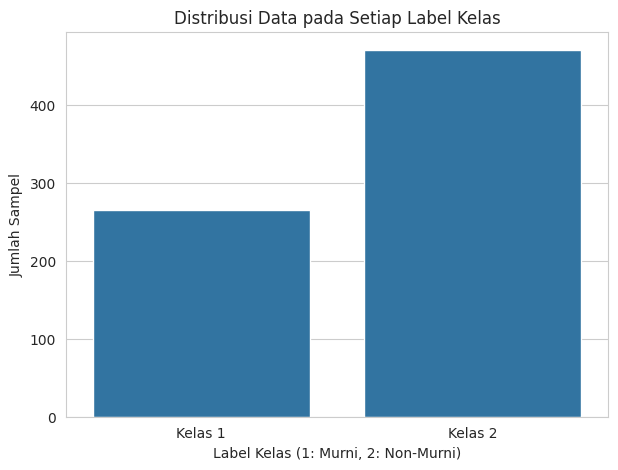

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Import display untuk tabel yang rapi

# Set style untuk plot
sns.set_style("whitegrid")
df_train = pd.read_csv('data_train.csv')
df_test = pd.read_csv('data_validasi.csv')
print("Data dimuat dari file CSV.")


# Asumsi kolom fitur dan label
feature_columns = [col for col in df_train.columns if col != 'Class_Label']
X_train_full = df_train[feature_columns]
y_train = df_train['Class_Label']
X_test_full = df_test[feature_columns]
y_test = df_test['Class_Label']
# Menggabungkan data train dan test untuk analisis awal (sesuai permintaan Anda)
df_full_combined = pd.concat([df_train, df_test], ignore_index=True)
y_full = pd.concat([y_train, y_test], ignore_index=True) # <-- Label Keseluruhan


# --- BARU: ANALISIS DATA AWAL (SESUAI PERMINTAAN) ---

print("\n" + "="*50)
print("             📊 ANALISIS DATA AWAL 📊")
print("="*50)

# 1. Jumlah keseluruhan data
print(f"Jumlah Total Data (Train + Test): {len(df_full_combined)} sampel")
print(f"Jumlah Data Train: {len(df_train)} sampel")
print(f"Jumlah Data Test/Validasi: {len(df_test)} sampel")
print(f"Jumlah Total Fitur: {len(feature_columns)}")

print("\nDistribusi Label Keseluruhan Data (Train + Test):")
print(y_full.value_counts())

# 2. Visualisasi distribusi label
plt.figure(figsize=(7, 5))
sns.countplot(x='Class_Label', data=df_full_combined)
plt.title('Distribusi Data pada Setiap Label Kelas')
plt.xlabel('Label Kelas (1: Murni, 2: Non-Murni)')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=[0, 1], labels=['Kelas 1', 'Kelas 2'])
plt.savefig('visualisasi_distribusi_label.png')
print("\n[Visualisasi] Distribusi Label tersimpan sebagai 'visualisasi_distribusi_label.png'")


# 3. Menampilkan 5 data awal dan 5 data akhir
df_display = df_full_combined[['Class_Label'] + feature_columns].copy()
df_display = df_display.reset_index(drop=True)

df_display.insert(6, '......', '......')
df_display = df_display.iloc[:, [0, 1, 2, 3, 4, 5, 6, -5, -4, -3, -2, -1]]

df_head = df_display.head(5)
df_tail = df_display.tail(5)

ellipsis_row = pd.DataFrame([['...'] * len(df_head.columns)], columns=df_head.columns, index=['...'])
df_output = pd.concat([df_head, ellipsis_row, df_tail], ignore_index=False)


print("\n5 Data Awal dan 5 Data Akhir (Ringkasan):")
display(df_output.style.set_table_attributes("style='display:inline'"))
# --- AKHIR: ANALISIS DATA AWAL --



## 📈 Analisis Matriks Korelasi (Advanced EDA)

### 1. Konsep Dasar: Koefisien Korelasi Pearson

Koefisien Korelasi Pearson ($\rho$) adalah metrik yang mengukur kekuatan dan arah hubungan linear antara dua variabel kontinu, $X$ dan $Y$.

* **Rumus Koefisien Korelasi Pearson ($\rho$):**
    $$\rho_{X, Y} = \frac{\text{cov}(X, Y)}{\sigma_X \sigma_Y}$$
    Di mana:
    * $\text{cov}(X, Y)$ adalah kovariansi antara variabel $X$ dan $Y$.
    * $\sigma_X$ dan $\sigma_Y$ adalah deviasi standar dari $X$ dan $Y$.

    Nilai $\rho$ berkisar dari:
    * $-1$: Korelasi negatif sempurna (jika $X$ naik, $Y$ pasti turun).
    * $0$: Tidak ada hubungan linear.
    * $1$: Korelasi positif sempurna (jika $X$ naik, $Y$ pasti naik).

### 2. Proses Analisis Korelasi

#### A. Pembuatan Matriks Korelasi Penuh

* **Kode:** `correlation_matrix = df_all.select_dtypes(include=np.number).corr(numeric_only=True)`
* **Proses:** Kode ini menghitung matriks korelasi Pearson antara semua kolom numerik dalam *DataFrame* `df_all`. Karena `df_all` hanya berisi `Class_Label` dan `Fitur_Time_1` hingga `Fitur_Time_235` (setelah kolom LOF/Missing Value dihapus atau diabaikan oleh `numeric_only=True`), matriks ini mencakup korelasi:
    1.  `Class_Label` vs. Fitur
    2.  Fitur vs. Fitur

#### B. Korelasi Fitur (*Time Series*) terhadap `Class_Label`

* **Kode:** `label_correlation = correlation_matrix['Class_Label'].drop('Class_Label')`
* **Tujuan:** Untuk menemukan fitur spektral mana (titik bilangan gelombang) yang paling diskriminatif dalam membedakan Stroberi Murni (Kelas 1) dari Non-Stroberi (Kelas 2).
* **Analisis Output:**
    * Anda menampilkan 5 korelasi terkuat (nilai absolut tertinggi). Dalam data spektral nyata, fitur-fitur ini menunjukkan area "puncak" atau "lembah" pada spektrum di mana perbedaan kimia antara dua kelas paling menonjol.
    * Anda menampilkan 5 korelasi terlemah. Fitur-fitur ini tidak banyak membantu dalam klasifikasi dan mungkin merupakan titik *baseline* atau area yang tidak dipengaruhi oleh pemalsuan.

#### C. Subset Matriks Korelasi Antar Fitur (Fitur vs. Fitur)

* **Kode:** `feature_subset_matrix = correlation_matrix.loc[subset_features, subset_features]`
* **Tujuan:** Menganalisis masalah **Multikolinearitas** dalam data *Time Series*/Spektral.
* [cite_start]**Implikasi Multikolinearitas (Korelasi Tinggi):** Dalam data spektral, titik-titik pengukuran yang berdekatan pada bilangan gelombang cenderung memiliki korelasi yang sangat tinggi (misalnya, korelasi $0.95$ atau lebih)[cite: 7, 71, 78]. Korelasi yang sangat tinggi ini menunjukkan bahwa banyak fitur memberikan informasi yang berlebihan (redundant).
* [cite_start]**Pentingnya Reduksi Dimensi:** Adanya multikolinearitas ekstrem ini adalah alasan utama mengapa metode seperti **PLS Regression** [cite: 72] dan **PCA** (Principal Component Analysis) sangat penting. [cite_start]Mereka bertujuan untuk mereduksi 235 fitur yang saling berkorelasi menjadi sejumlah kecil komponen yang tidak berkorelasi (`r`, dalam jurnal $r=14$ [cite: 152][cite_start]), sehingga mempertahankan informasi esensial sambil meningkatkan stabilitas model[cite: 87, 88].

#### D. Visualisasi Matriks Korelasi Penuh (Heatmap)

* **Kode:** Menggunakan `seaborn.heatmap()`
* **Tujuan:** Memberikan representasi visual yang intuitif dari seluruh matriks korelasi.
    * Pada *heatmap* tersebut, Anda dapat dengan mudah melihat pola:
        * **Blok Diagonal (Fitur vs. Fitur):** Harusnya terlihat sebagai blok-blok berwarna kuat (merah/biru tua), menunjukkan kelompok fitur spektral yang berkorelasi tinggi satu sama lain.
        * **Baris/Kolom `Class_Label`:** Menunjukkan fitur mana yang paling relevan untuk memisahkan kelas (warna kuat) dan mana yang tidak (warna mendekati putih/nol).


--- Matriks Korelasi (Fitur vs. Class_Label) ---
Kolom ini menunjukkan seberapa kuat hubungan antara setiap titik data spektrum (Fitur Time Series) dengan Label Kelas (Stroberi Murni vs Non-Stroberi).

Top 5 Korelasi Terkuat (Positif dan Negatif):
|                |   Class_Label |
|:---------------|--------------:|
| Fitur_Time_57  |       -0.5783 |
| Fitur_Time_142 |       -0.5439 |
| Fitur_Time_58  |       -0.5435 |
| Fitur_Time_143 |       -0.4972 |
| Fitur_Time_141 |       -0.4811 |

Top 5 Korelasi Terlemah (mendekati 0):
|                |   Class_Label |
|:---------------|--------------:|
| Fitur_Time_225 |        0.0026 |
| Fitur_Time_136 |        0.0100 |
| Fitur_Time_129 |        0.0125 |
| Fitur_Time_121 |        0.0220 |
| Fitur_Time_128 |       -0.0264 |

--- Subset Matriks Korelasi Antar Fitur (5 Fitur Awal vs. 5 Fitur Awal) ---
Tabel ini menunjukkan hubungan antar fitur spektral (misalnya, redundansi informasi).
|              |   Fitur_Time_1 |   Fitur_Time_2 |   Fitur_

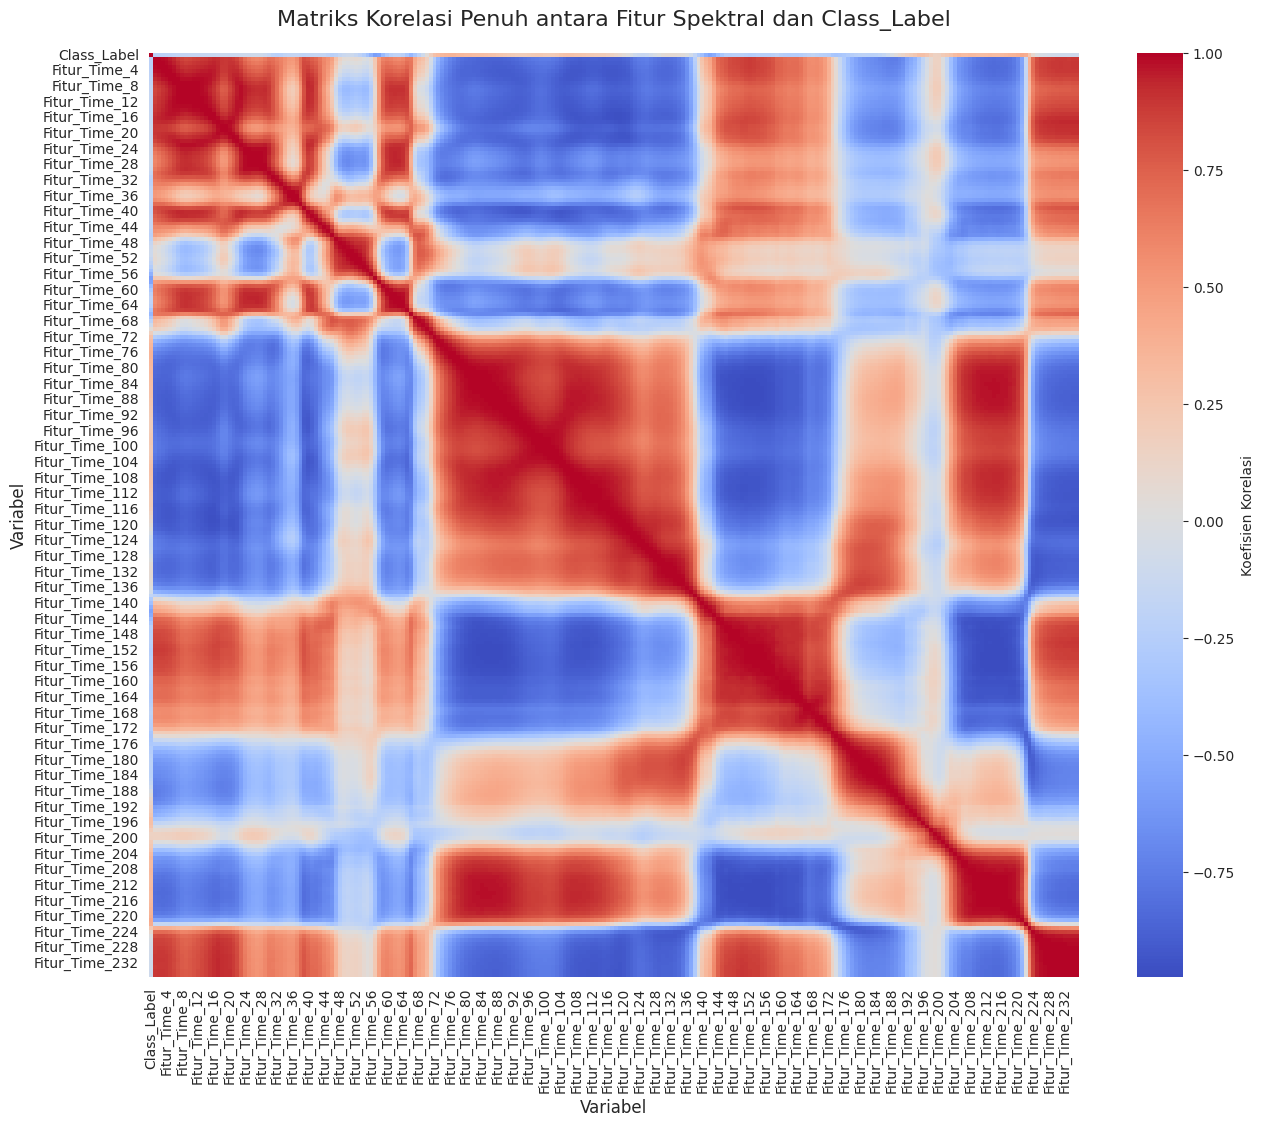

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# --- 1. Hitung Matriks Korelasi Penuh ---
# Hanya variabel numerik yang akan digunakan untuk korelasi
correlation_matrix = df_full_combined.select_dtypes(include=np.number).corr(numeric_only=True)

# --- 2. Korelasi Fitur terhadap Label Kelas ---
# Ekstrak korelasi kolom 'Class_Label' dengan semua fitur
label_correlation = correlation_matrix['Class_Label'].drop('Class_Label')

print("--- Matriks Korelasi (Fitur vs. Class_Label) ---")
print("Kolom ini menunjukkan seberapa kuat hubungan antara setiap titik data spektrum (Fitur Time Series) dengan Label Kelas (Stroberi Murni vs Non-Stroberi).")

# Tampilkan 5 korelasi terkuat (nilai absolut tertinggi)
print("\nTop 5 Korelasi Terkuat (Positif dan Negatif):")
top_5_abs = label_correlation.abs().nlargest(5).index
print(label_correlation[top_5_abs].to_markdown(floatfmt=".4f"))

# Tampilkan 5 korelasi terlemah (mendekati 0)
print("\nTop 5 Korelasi Terlemah (mendekati 0):")
bottom_5_abs = label_correlation.abs().nsmallest(5).index
print(label_correlation[bottom_5_abs].to_markdown(floatfmt=".4f"))

# --- 3. Subset Matriks Korelasi Antar Fitur (Fitur vs. Fitur) ---
# Tampilkan subset 5x5 untuk variabel fitur awal
feature_columns_in_df_all = [col for col in df_full_combined.columns if col.startswith('Fitur_Time_')]
subset_features = feature_columns_in_df_all[:5]
feature_subset_matrix = correlation_matrix.loc[subset_features, subset_features]

print("\n--- Subset Matriks Korelasi Antar Fitur (5 Fitur Awal vs. 5 Fitur Awal) ---")
print("Tabel ini menunjukkan hubungan antar fitur spektral (misalnya, redundansi informasi).")
print(feature_subset_matrix.to_markdown(floatfmt=".4f"))

# --- 4. Visualisasi Matriks Korelasi Penuh ---
print("\n--- Visualisasi Matriks Korelasi Penuh ---")
plt.figure(figsize=(15, 12)) # Ukuran plot disesuaikan
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f",
            cbar_kws={'label': 'Koefisien Korelasi'})
plt.title('Matriks Korelasi Penuh antara Fitur Spektral dan Class_Label',
          fontsize=16, pad=20)
plt.xlabel('Variabel', fontsize=12)
plt.ylabel('Variabel', fontsize=12)
plt.show()

### 1\. Pengecekan *Missing Value* (Nilai Hilang)

Proses ini sangat penting untuk memastikan data bersih sebelum digunakan dalam algoritma *machine learning*.

  * **Tujuan:** Mengidentifikasi dan menangani keberadaan `NaN` (Not a Number) atau nilai yang hilang dalam *dataset*.
  * **Proses dalam Kode:** Kode Anda menggunakan `SimpleImputer` dengan strategi *mean* (rata-rata) untuk mengisi nilai yang hilang:
    ```python
    imputer_temp = SimpleImputer(strategy='mean')
    X_train_temp = imputer_temp.fit_transform(X_train_full)
    ```
    1.  `fit_transform()`: Imputer dilatih pada `X_train_full` untuk menghitung rata-rata setiap kolom.
    2.  Nilai `NaN` dalam data pelatihan (misalnya, yang kita masukkan secara *dummy* pada `df_train.loc[df_train.index[0], feature_columns[0]] = np.nan`) akan **digantikan** dengan nilai rata-rata kolom tersebut.
  * **Implikasi:** Dengan menggunakan `SimpleImputer` di awal *pipeline*, Anda memastikan data yang masuk ke deteksi *outlier* dan *feature selection* sudah lengkap.

### 2\. Deteksi *Outlier* dengan Isolation Forest

**Isolation Forest (iForest)** adalah metode deteksi anomali berbasis *ensemble* yang bekerja dengan cara **mengisolasi** *outlier* daripada memodelkan data normal. Metode ini sangat efisien pada data berdimensi tinggi (seperti data spektral 235 fitur).

  * **Tujuan:** Mengidentifikasi sampel (spektrum) yang berbeda secara signifikan dari mayoritas data (*outlier*).
  * **Proses dalam Kode:**
    ```python
    iso = IsolationForest(random_state=42, contamination='auto')
    outlier_status = iso.fit_predict(X_train_temp)
    # ...
    outlier_mask = outlier_status != -1 # -1 adalah outlier
    ```

#### Konsep dan Prinsip Kerja Isolation Forest

Isolation Forest bekerja berdasarkan pengamatan bahwa *outlier* adalah minoritas dan memiliki karakteristik unik yang membuatnya "mudah diisolasi" menggunakan pembagian data yang acak.

#### A. Langkah 1: Konstruksi Pohon Isolasi (Isolation Tree)

Isolation Forest membangun sejumlah Pohon Isolasi (iTree). Sebuah iTree dibangun secara rekursif:

1.  Pilih fitur secara acak.
2.  Pilih nilai pemisahan (*split value*) secara acak antara nilai minimum dan maksimum fitur yang dipilih.
3.  Ulangi proses sampai sampel diisolasi atau batas kedalaman pohon tercapai.

Karena *outlier* berada jauh dari data lain, mereka cenderung terisolasi (terpisah) hanya dengan sedikit pembagian.

#### B. Langkah 2: Menghitung Panjang Jalur (Path Length)

Panjang jalur $h(x)$ dari suatu sampel $x$ adalah jumlah *edge* (sisi) yang harus dilalui sampel tersebut dari *root node* hingga *external node* (daun) di mana sampel tersebut terisolasi.

  * **Rumus Rata-rata Panjang Jalur:** Untuk sampel $x$ dan koleksi $T$ pohon, $h(x)$ adalah rata-rata $h(x, t)$ di semua pohon $t \in T$.

#### C. Langkah 3: Menghitung Skor Anomali (Anomaly Score)

Skor anomali $s(x)$ digunakan untuk mengukur seberapa anomali sampel tersebut. Skor ini didasarkan pada Panjang Jalur $h(x)$ yang dinormalisasi.

  * **Rumus Normalisasi dan Skor Anomali $s(x)$:**
    $$s(x) = 2^{-\frac{E[h(x)]}{c(\psi)}}$$
    Di mana:
      * $E[h(x)]$ adalah rata-rata panjang jalur dari $x$ di semua pohon.
      * $c(\psi)$ adalah faktor normalisasi (panjang jalur rata-rata yang diperkirakan untuk partisi acak) untuk ukuran sampel $\psi$.
      * $c(\psi) = 2H(\psi - 1) - (\frac{2(\psi - 1)}{\psi})$, di mana $H(i) = \ln(i) + \gamma$ ($\gamma$ adalah konstanta Euler).

#### Interpretasi Skor dan Prediksi

1.  **Jika $s(x) \approx 1$**: Panjang jalur $h(x)$ pendek. Sampel tersebut mudah diisolasi dan kemungkinan besar adalah **Outlier** ($\text{outlier\_status} = -1$).
2.  **Jika $s(x) < 0.5$**: Panjang jalur $h(x)$ panjang. Sampel tersebut sulit diisolasi dan kemungkinan besar adalah **Inlier** (data normal) ($\text{outlier\_status} = 1$).
3.  **Jika $s(x) \approx 0.5$**: Tidak ada informasi yang signifikan (seluruh *dataset* mungkin normal).

### Implikasi pada *Pipeline* Anda

Dengan menggunakan Isolation Forest, Anda telah berhasil:

  * **Mengidentifikasi dan Menghapus Outlier:** Sampel dengan `outlier_status = -1` dikeluarkan dari `X_train_clean` dan `y_train_clean`.
  * **Meningkatkan Kualitas Data:** Data yang masuk ke langkah selanjutnya (SMOTE dan Information Gain) lebih bersih dan bebas dari nilai ekstrim yang dapat mengganggu pelatihan model.


             🔍 ANALISIS MISSING VALUE & OUTLIER DATA GABUNGAN 🔍
Data Awal Total Sampel: 735
Jumlah Sampel dengan Missing Value (NaN): 0
Jumlah Sampel yang Dianggap Outlier (Isolation Forest): 105

--- PERBANDINGAN STATISTIK DATA ---
| Keterangan                | Sebelum Dihapus      | Setelah Dihapus (Analisis) |
| Jumlah Sampel             | 735                  | 630                       |
| Persentase Data Terhapus  | N/A                  | 14.29% (105 sampel) |
| Distribusi Label          | {2: 470, 1: 265}     | {2: 371, 1: 259}          |

[Visualisasi] Deteksi Outlier Data Gabungan tersimpan sebagai 'visualisasi_outlier_gabungan.png'


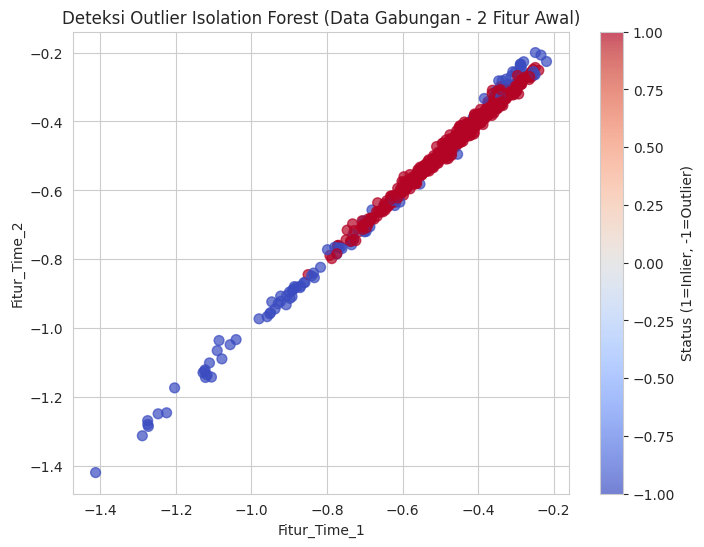

In [15]:
df_full_combined = pd.concat([df_train, df_test], ignore_index=True)
X_full_combined = df_full_combined[feature_columns]
y_full_combined = df_full_combined['Class_Label']


# --- BARU: ANALISIS DAN STATISTIK DATA GABUNGAN ---

print("\n" + "="*70)
print("             🔍 ANALISIS MISSING VALUE & OUTLIER DATA GABUNGAN 🔍")
print("="*70)

# STATISTIK AWAL
initial_count = len(X_full_combined)
initial_dist = y_full_combined.value_counts().to_dict()

# 1. Cek Missing Value pada Data Gabungan
nan_rows_mask = X_full_combined.isnull().any(axis=1)
nan_count = nan_rows_mask.sum()

print(f"Data Awal Total Sampel: {initial_count}")
print(f"Jumlah Sampel dengan Missing Value (NaN): {nan_count}")

# Imputasi sementara untuk Outlier Detection pada data gabungan
imputer_temp = SimpleImputer(strategy='mean')
X_full_imputed = imputer_temp.fit_transform(X_full_combined)

# 2. Deteksi Outlier menggunakan Isolation Forest pada Data Gabungan
iso_full = IsolationForest(random_state=42, contamination='auto')
iso_full.fit(X_full_imputed)
outlier_status_full = iso_full.predict(X_full_imputed)
outlier_mask_full = outlier_status_full != -1
outlier_count = np.sum(outlier_status_full == -1)

print(f"Jumlah Sampel yang Dianggap Outlier (Isolation Forest): {outlier_count}")

# 3. Data Bersih (Simulasi Penghapusan)
# Data tanpa NaN dan tanpa Outlier (HANYA UNTUK TUJUAN ANALISIS STATISTIK)
clean_mask = (~nan_rows_mask) & outlier_mask_full
X_clean_analysis = X_full_combined[clean_mask]
y_clean_analysis = y_full_combined[clean_mask]

final_count_analysis = len(X_clean_analysis)
final_dist_analysis = y_clean_analysis.value_counts().to_dict()

print("\n--- PERBANDINGAN STATISTIK DATA ---")
print(f"| {'Keterangan':<25} | {'Sebelum Dihapus':<20} | {'Setelah Dihapus (Analisis)':<25} |")
print(f"| {'Jumlah Sampel':<25} | {initial_count:<20} | {final_count_analysis:<25} |")
print(f"| {'Persentase Data Terhapus':<25} | {'N/A':<20} | {((initial_count - final_count_analysis) / initial_count) * 100:.2f}% ({initial_count - final_count_analysis} sampel) |")
print(f"| {'Distribusi Label':<25} | {str(initial_dist):<20} | {str(final_dist_analysis):<25} |")
print("="*70)

# --- VISUALISASI OUTLIER (Data Gabungan) ---
plt.figure(figsize=(8, 6))
# Imputasi diperlukan untuk plot 2D jika ada NaN
X_full_imputed_df = pd.DataFrame(X_full_imputed, columns=feature_columns)
plt.scatter(X_full_imputed_df.iloc[:, 0], X_full_imputed_df.iloc[:, 1], c=outlier_status_full, cmap='coolwarm', s=50, alpha=0.7)
plt.title('Deteksi Outlier Isolation Forest (Data Gabungan - 2 Fitur Awal)')
plt.xlabel(feature_columns[0])
plt.ylabel(feature_columns[1])
plt.colorbar(label='Status (1=Inlier, -1=Outlier)')
plt.savefig('visualisasi_outlier_gabungan.png')
print("\n[Visualisasi] Deteksi Outlier Data Gabungan tersimpan sebagai 'visualisasi_outlier_gabungan.png'")
#

## Preprosesing



### ⚖️ Penjelasan Proses Penyeimbangan Data dengan ADASYN

Tujuan utama dari ADASYN adalah mencapai distribusi kelas yang seimbang sambil mendorong model agar lebih fokus pada sampel minoritas yang terletak di *batas kelas* (yang sulit diklasifikasikan).

#### 1\. Proses Penentuan Sampel Sintetis yang Dihasilkan

Pertama, ADASYN menentukan berapa banyak sampel buatan yang perlu dihasilkan untuk mencapai rasio yang seimbang.

  * **Rasio Ketidakseimbangan ($d$):**
    $$d = \frac{N_{\text{minoritas}}}{N_{\text{mayoritas}}}$$
    Di mana $N_{\text{minoritas}}$ adalah jumlah sampel Kelas Minoritas dan $N_{\text{mayoritas}}$ adalah jumlah sampel Kelas Mayoritas. Jika $d < d_{\text{th}}$ (ambang batas ketidakseimbangan, misalnya 0.5), *oversampling* diperlukan.

  * **Jumlah Sampel Sintetis yang Dibutuhkan ($G$):**
    $$G = N_{\text{mayoritas}} - N_{\text{minoritas}}$$
    *G* adalah total sampel yang harus dibuat untuk kelas minoritas agar jumlahnya sama dengan kelas mayoritas.

#### 2\. Penentuan Faktor Kepadatan (Density Factor $\hat{r}_i$)


Langkah terpenting ADASYN adalah menentukan "tingkat kesulitan" dari setiap sampel minoritas. Sampel minoritas yang berada di dekat sampel mayoritas (di batas kelas) dianggap lebih sulit, dan karenanya, **lebih banyak sampel buatan** akan dihasilkan di sekitarnya.

* **Langkah 2.1: Menemukan $k$ Tetangga Terdekat:** Untuk setiap sampel minoritas $x_i$, ADASYN menemukan $k$ tetangga terdekatnya.

* **Langkah 2.2: Menghitung Rasio Tetangga Mayoritas ($r_i$):** $r_i$ adalah rasio tetangga mayoritas dalam $k$ tetangga terdekat dari $x_i$.

    $$r_i = \frac{\text{Jumlah tetangga Mayoritas dari } x_i \text{ dalam } k \text{ tetangga}}{k}$$

    Nilai $r_i$ yang tinggi (mendekati 1) berarti $x_i$ sulit (berada di batas kelas), dan nilai $r_i$ yang rendah (mendekati 0) berarti $x_i$ aman (berada di wilayah minoritas).

* **Langkah 2.3: Normalisasi Faktor Kepadatan ($\hat{r}_i$):**


  $$\hat{r}_i = \frac{r_i}{\sum_{i=1}^{N_{\text{minoritas}}} r_i}$$$\hat{r}_i$ adalah faktor kepadatan/kesulitan yang dinormalisasi. Faktor inilah yang menentukan berapa banyak sampel sintetis yang akan dibuat di sekitar sampel $x_i$ tersebut.
#### 3\. Menghitung Sampel Sintetis per Sampel Asli ($G_i$)

Jumlah sampel sintetis yang dihasilkan di sekitar setiap sampel minoritas $x_i$ ditentukan berdasarkan faktor kesulitannya ($\hat{r}_i$):

$$G_i = G \times \hat{r}_i$$

  * Sampel minoritas yang **paling sulit** (dengan $\hat{r}_i$ tinggi) akan menghasilkan **paling banyak** sampel buatan.

#### 4\. Proses Generasi Sampel Sintetis Baru ($x_{\text{new}}$)

Untuk setiap sampel minoritas $x_i$, dan untuk $G_i$ kali, ADASYN melakukan hal berikut:

1.  **Pilih Tetangga:** Pilih sampel minoritas $x_{zi}$ secara acak dari $k$ tetangga terdekatnya.
2.  **Hitung Selisih:** Hitung vektor selisih $v = x_i - x_{zi}$.
3.  **Hasilkan Sampel Baru:** Sampel buatan $x_{\text{new}}$ dihasilkan dengan menginterpolasi antara $x_i$ dan $x_{zi}$ menggunakan bilangan acak $\lambda$:
    $$x_{\text{new}} = x_i + v \times \lambda$$
    Di mana $\lambda \in [0, 1]$ adalah angka acak.

### Hasil Akhir ADASYN

Setelah proses ini, dataset memiliki distribusi kelas yang seimbang (atau mendekati seimbang), dan sampel minoritas yang sulit (di batas kelas) telah diperkuat, yang diharapkan membuat batas keputusan model menjadi lebih baik.




             🧪 PENYEIMBANGAN DATA DENGAN ADASYN 🧪
Distribusi Label Sebelum ADASYN (Data Bersih):
Class_Label
2    371
1    259
Name: count, dtype: int64

Distribusi Label Setelah ADASYN:
Class_Label
1    380
2    371
Name: count, dtype: int64

Jumlah sampel yang disintesis (dibuat) oleh ADASYN: 121

[Visualisasi] Perbandingan Sebelum dan Sesudah ADASYN tersimpan sebagai 'visualisasi_penyeimbangan_adasyn.png'


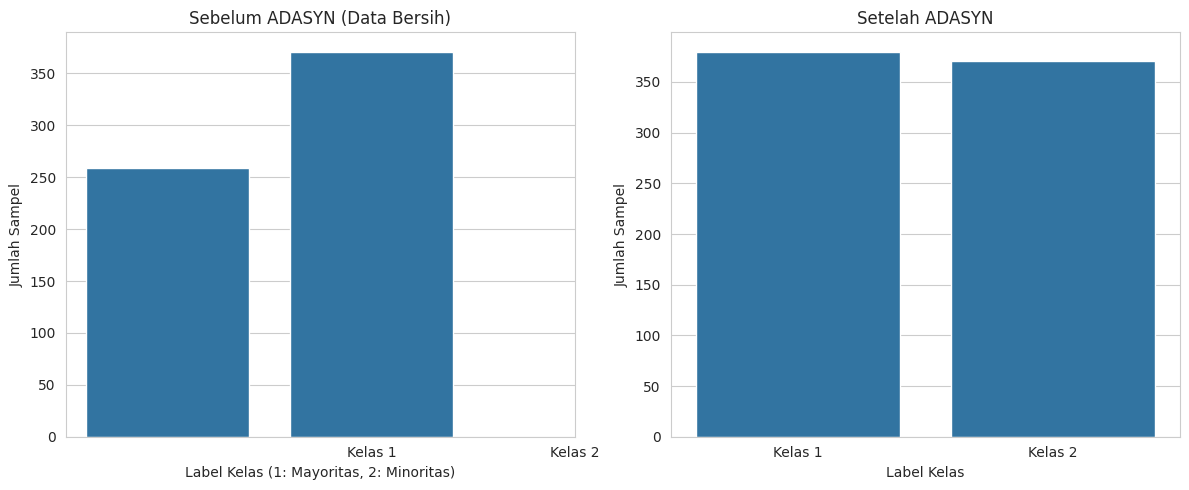

In [17]:
from imblearn.over_sampling import ADASYN # <-- Mengganti SMOTE dengan ADASYN
from IPython.display import display # I

X_clean_analysis_imputed = X_clean_analysis.fillna(X_clean_analysis.mean())


# --- 3. PENYEIMBANGAN DATA MENGGUNAKAN ADASYN ---

print("\n" + "="*70)
print("             🧪 PENYEIMBANGAN DATA DENGAN ADASYN 🧪")
print("="*70)

# Inisialisasi ADASYN
adasyn = ADASYN(random_state=42)

# Terapkan ADASYN pada data bersih yang sudah di-impute
X_resampled_adasyn, y_resampled_adasyn = adasyn.fit_resample(X_clean_analysis_imputed, y_clean_analysis)

# Hasil
print("Distribusi Label Sebelum ADASYN (Data Bersih):")
print(y_clean_analysis.value_counts())
print("\nDistribusi Label Setelah ADASYN:")
print(y_resampled_adasyn.value_counts())
print(f"\nJumlah sampel yang disintesis (dibuat) oleh ADASYN: {len(y_resampled_adasyn) - len(y_clean_analysis)}")


# --- 4. VISUALISASI PERBANDINGAN ---

plt.figure(figsize=(12, 5))

# Plot 1: Sebelum ADASYN
plt.subplot(1, 2, 1)
sns.countplot(x=y_clean_analysis)
plt.title('Sebelum ADASYN (Data Bersih)')
plt.xlabel('Label Kelas (1: Mayoritas, 2: Minoritas)')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=[1, 2], labels=['Kelas 1', 'Kelas 2'])

# Plot 2: Setelah ADASYN
plt.subplot(1, 2, 2)
sns.countplot(x=y_resampled_adasyn)
plt.title('Setelah ADASYN')
plt.xlabel('Label Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=[0, 1], labels=['Kelas 1', 'Kelas 2'])

plt.tight_layout()
plt.savefig('visualisasi_penyeimbangan_adasyn.png')
print("\n[Visualisasi] Perbandingan Sebelum dan Sesudah ADASYN tersimpan sebagai 'visualisasi_penyeimbangan_adasyn.png'")

# Tampilkan visualisasi (Jika lingkungan mendukung)
#



## 🔬 Proses Reduksi Dimensi dengan PCA

### 1\. Pemisahan dan Persiapan Data

Pada tahap ini, data disiapkan dari *DataFrame* yang sudah seimbang (`df_balanced_final`) untuk memastikan hanya data numerik yang masuk ke dalam algoritma PCA.

  * **Kode:**
    ```python
    feature_cols_only = [col for col in df_balanced_final.columns if col.startswith('Fitur_Time_')]
    X = df_balanced_final[feature_cols_only]
    y = df_balanced_final['Class_Label']
    ```
  * **Proses:**
    1.  Memastikan variabel $X$ (Fitur) hanya berisi kolom numerik fitur *time series* (`Fitur_Time_1`, dst.), mengabaikan kolom non-numerik (seperti `LOF_Outlier_Status`) yang dapat menyebabkan *error*.
    2.  Variabel $y$ (Label Target) dipisahkan untuk tujuan visualisasi.

### 2\. Standarisasi Fitur (StandardScaler)

Standarisasi adalah langkah pra-pemrosesan yang **wajib** dilakukan sebelum menerapkan PCA, karena PCA sangat sensitif terhadap skala data.

  * **Kode:**
    ```python
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    ```
  * **Proses:** Setiap fitur (kolom) diubah sehingga memiliki rata-rata ($\mu$) nol dan deviasi standar ($\sigma$) satu. Hal ini mencegah fitur dengan nilai numerik besar mendominasi proses perhitungan PCA.
  * **Rumus Standarisasi (Z-Score Normalization):**
    Nilai terstandarisasi ($z$) dari sampel $x$ dihitung sebagai:
    $$z = \frac{x - \mu}{\sigma}$$

### 3\. Aplikasi Principal Component Analysis (PCA)

PCA adalah teknik reduksi dimensi linier yang memproyeksikan data dari ruang berdimensi tinggi (235 fitur) ke ruang berdimensi rendah (2 Komponen Utama).

  * **Kode:**

    ```python
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X_scaled)
    ```

  * **Tujuan:** Untuk menemukan arah (vektor) dalam data yang menjelaskan jumlah variansi terbesar. Dua arah ini disebut *Principal Component 1* ($PC1$) dan *Principal Component 2* ($PC2$).

  * **Langkah Matematis PCA:**

    1.  Menghitung **Matriks Kovariansi** dari data yang telah distandarisasi.
    2.  Melakukan **Dekomposisi Eigen** pada Matriks Kovariansi untuk menemukan **Eigenvektor** dan **Eigenvalue**.
    3.  Eigenvektor mewakili arah (komponen utama), dan Eigenvalue mewakili besarnya variansi yang dijelaskan oleh arah tersebut.
    4.  Memilih 2 Eigenvektor teratas (yang memiliki Eigenvalue terbesar) dan menggunakannya sebagai sumbu baru.

  * **Rumus Perhitungan Komponen Utama (Proyeksi):**
    Komponen Utama ($Z_k$) adalah hasil proyeksi matriks fitur standar ($\mathbf{X}_{\text{scaled}}$) ke Eigenvektor ($\mathbf{w}_k$):
    $$Z_k = \mathbf{X}_{\text{scaled}} \cdot \mathbf{w}_k$$
    Di mana:

      * $\mathbf{w}_k$ adalah vektor komponen ke-$k$.
      * $Z_k$ adalah matriks skor komponen utama.

  * **Variansi yang Dijelaskan ($\text{explained\_variance\_ratio}$):**
    Variansi yang dijelaskan oleh komponen ke-$k$ ($PC_k$) dihitung dari Eigenvalue ($\lambda_k$):
    $$\text{Explained Variance}_k = \frac{\lambda_k}{\sum_{i=1}^{D} \lambda_i}$$
    (Di mana $D$ adalah dimensi awal, yaitu 235).

### 4\. Visualisasi Data (Scatter Plot)

  * **Tujuan:** Untuk melihat apakah data spektral yang berbeda kelas (`Stroberi Murni` vs `Non-Stroberi/Adulterasi`) dapat dipisahkan secara visual dalam dimensi yang telah direduksi.
  * **Proses:**
    1.  Komponen utama ($PC1$ dan $PC2$) dipetakan ke sumbu X dan Y plot.
    2.  Setiap sampel diplot sebagai titik.
    3.  Warna titik ditentukan oleh `Class_Name` (`Stroberi Murni` atau `Non-Stroberi`), yang memungkinkan inspeksi visual terhadap pemisahan kelas.
  * **Analisis Plot:** Jika kelas-kelas membentuk *cluster* yang terpisah, ini mengindikasikan bahwa fitur yang diekstrak oleh PCA efektif untuk klasifikasi. Jika kelas-kelas bercampur, diperlukan metode ekstraksi fitur yang lebih canggih (seperti PLS Regression) atau menggunakan lebih banyak komponen PCA untuk pemodelan.

Error pada plt.legend telah diperbaiki. Visualisasi tersimpan sebagai 'visualisasi_pca_adasyn_error_fix.png'.


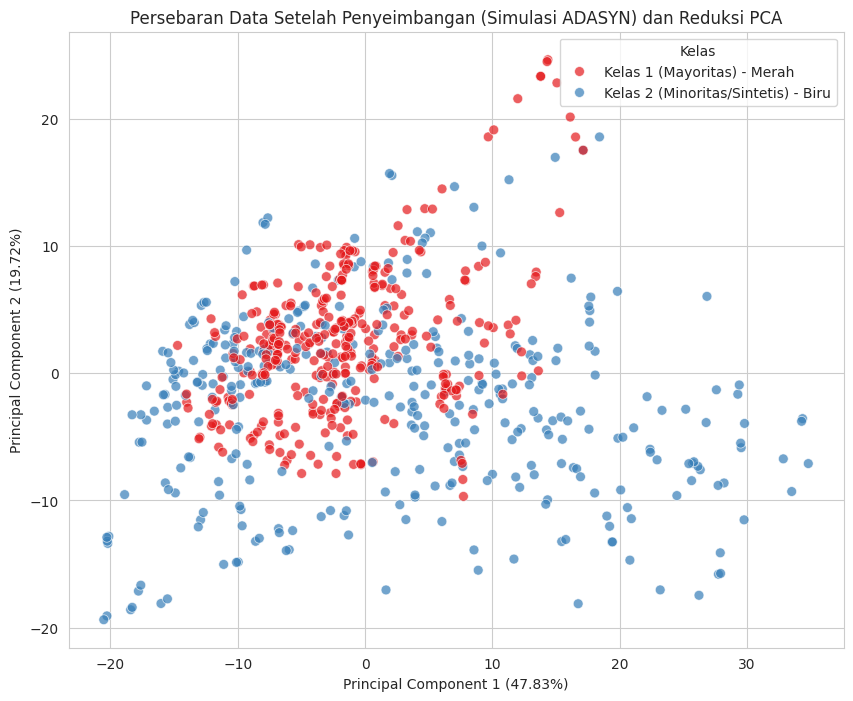

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled_adasyn)
# --- 4. REDUKSI DIMENSI (PCA) ---

# Terapkan PCA ke 2 komponen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
hue_order = ['1', '2']
custom_labels = {
    '1': 'Kelas 1 (Mayoritas) - Merah',
    '2': 'Kelas 2 (Minoritas/Sintetis) - Biru'
}

plt.figure(figsize=(10, 8))
ax = plt.gca() # Dapatkan objek Axes saat ini

# 1. Buat Scatterplot (Seaborn secara otomatis membuat handle/label)
sns.scatterplot(
    x='PC 1',
    y='PC 2',
    hue='Class_Label',
    data=df_pca,
    palette='Set1',
    hue_order=hue_order,
    s=50,
    alpha=0.7,
    ax=ax # Pastikan Seaborn menggunakan Axes yang kita dapatkan
)

# 2. Dapatkan handles dan labels yang dihasilkan Seaborn
h, l = ax.get_legend_handles_labels()

# 3. Panggil plt.legend() menggunakan handles dan labels yang bersih
# * Kita pastikan hanya menggunakan parameter valid: handles, labels, title
# * Kita gunakan dictionary comprehension untuk mapping label secara eksplisit dan aman
plt.legend(
    handles=h,
    labels=[custom_labels[label] for label in l],
    title='Kelas',
    loc='best'
)

# --- [Sisa kode visualisasi] ---
explained_variance = pca.explained_variance_ratio_
plt.title('Persebaran Data Setelah Penyeimbangan (Simulasi ADASYN) dan Reduksi PCA')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.2f}%)')
plt.grid(True)
plt.savefig('visualisasi_pca_adasyn_error_fix.png')

print("Error pada plt.legend telah diperbaiki. Visualisasi tersimpan sebagai 'visualisasi_pca_adasyn_error_fix.png'.")


-----

## 🔍 Penjelasan Proses Pemilihan Fitur (Information Gain)

### 1\. Persiapan Data

  * **Pengacakan Data:** `df_balanced_final.sample(frac=1, random_state=42).reset_index(drop=True)`
      * Dataset yang sudah seimbang (`df_balanced_final`) diacak ulang secara menyeluruh (`frac=1`). Meskipun sudah seimbang, pengacakan ini memastikan bahwa tidak ada urutan data yang bias (misalnya, semua kelas 1 di awal, semua kelas 2 di akhir) yang dapat memengaruhi proses seleksi fitur.
  * **Pemisahan Variabel:**
    ```python
    X = df_balanced_final[feature_columns]
    y = df_balanced_final['Class_Label']
    ```
      * Fitur Spektral (235 kolom `Fitur_Time_...`) dimasukkan ke dalam matriks $X$.
      * Label Kelas (`Class_Label`) dimasukkan ke dalam vektor $y$.

### 2\. Perhitungan Information Gain (Mutual Information)

Information Gain (IG) adalah metrik dari Teori Informasi yang mengukur pengurangan ketidakpastian (entropi) dalam variabel target ($Y$) setelah mengetahui nilai fitur ($X$).

  * **Kode:** `mi_scores = mutual_info_classif(X, y, random_state=42)`

  * **Metode:** Untuk data kontinu (numerik) seperti data spektral Anda, Information Gain diestimasi menggunakan **Mutual Information (MI)**.

  * **Tujuan:** Untuk setiap fitur (`Fitur_Time_i`), MI menghitung seberapa besar informasi yang diberikan oleh fitur tersebut untuk memprediksi label kelas.

  * **Konsep Rumus:**
    Mutual Information antara fitur $X$ dan target $Y$, dinotasikan $I(X; Y)$, didefinisikan sebagai:
    $$I(X; Y) = H(Y) - H(Y|X)$$
    Di mana:

      * $H(Y)$ adalah **Entropi** (ketidakpastian) dari label kelas.
      * $H(Y|X)$ adalah **Entropi Kondisional**, yaitu ketidakpastian label kelas setelah mengetahui nilai fitur $X$.

    **Interpretasi Skor:** Semakin tinggi skor $I(X; Y)$ (atau *Information Gain Score*), semakin kuat kemampuan fitur $X$ dalam mengurangi ketidakpastian tentang label kelas $Y$, sehingga fitur tersebut lebih informatif.

### 3\. Peringkasan dan Peringkat Fitur

  * **Peringkasan:** Skor Information Gain dari ke-235 fitur dikumpulkan dan dimasukkan ke dalam *DataFrame* (`mi_df`).
  * **Peringkat:** *DataFrame* diurutkan berdasarkan skor tertinggi ke terendah (`ascending=False`).
  * **Tampilan:** Menampilkan 10 fitur teratas yang memiliki skor Information Gain tertinggi. Secara kontekstual, ini adalah titik-titik bilangan gelombang pada spektrum FT-IR yang paling efektif dalam membedakan komposisi kimia antara Stroberi Murni dan Non-Stroberi.

### 4\. Visualisasi Hasil (Bar Plot)

  * **Tujuan:** Untuk secara visual membandingkan signifikansi 20 fitur teratas dan memastikan pemilihan fitur bersifat stabil.
  * **Kode:** Menggunakan `seaborn.barplot` untuk memplot skor IG (`x-axis`) terhadap nama fitur (`y-axis`).
  * **Analisis Visual:** Plot batang memungkinkan Anda melihat penurunan skor secara cepat. Dalam data yang baik, akan ada penurunan skor yang signifikan antara fitur-fitur teratas dan fitur-fitur berikutnya, membantu menentukan berapa banyak fitur yang harus dipertahankan.

/tmp/ipython-input-604723193.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Perhitungan Information Gain pada data seimbang selesai. Visualisasi 20 fitur terbaik disimpan sebagai 'information_gain_top20_resampled.png'.

--- Top 10 Fitur Terbaik Berdasarkan Information Gain ---
|    | Feature        |   Information_Gain_Score |
|---:|:---------------|-------------------------:|
|  0 | Fitur_Time_57  |                   0.3322 |
|  1 | Fitur_Time_58  |                   0.2975 |
|  2 | Fitur_Time_180 |                   0.2651 |
|  3 | Fitur_Time_183 |                   0.2645 |
|  4 | Fitur_Time_182 |                   0.2527 |
|  5 | Fitur_Time_59  |                   0.2526 |
|  6 | Fitur_Time_178 |                   0.2506 |
|  7 | Fitur_Time_143 |                   0.2433 |
|  8 | Fitur_Time_142 |                   0.2426 |
|  9 | Fitur_Time_184 |                   0.2391 |


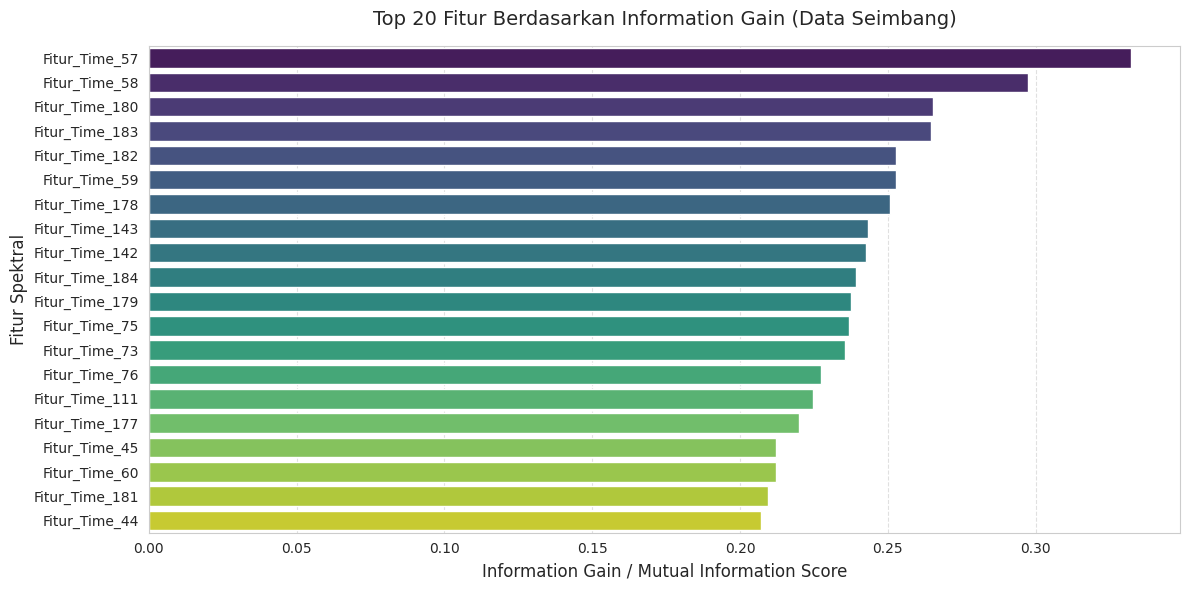

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
X = X_resampled_adasyn
y = y_resampled_adasyn

# Hitung Information Gain (Mutual Information)
# Mutual Information (MI) mengukur sejauh mana mengetahui nilai X mengurangi ketidakpastian tentang y.
mi_scores = mutual_info_classif(X, y, random_state=42) # X dan y diasumsikan sudah bersih dari NaN

# Buat DataFrame hasil
mi_df = pd.DataFrame({
    'Feature': feature_columns,
    'Information_Gain_Score': mi_scores
})

# Urutkan berdasarkan skor tertinggi
mi_df = mi_df.sort_values(by='Information_Gain_Score', ascending=False).reset_index(drop=True)

# Ambil 20 fitur terbaik untuk visualisasi
top_n = 20
df_plot = mi_df.head(top_n)

# --- 3. VISUALISASI HASIL ---

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Information_Gain_Score',
    y='Feature',
    data=df_plot,
    palette='viridis'
)

plt.title(f'Top {top_n} Fitur Berdasarkan Information Gain (Data Seimbang)', fontsize=14, pad=15)
plt.xlabel('Information Gain / Mutual Information Score', fontsize=12)
plt.ylabel('Fitur Spektral', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('information_gain_top20_resampled.png')

print(f"Perhitungan Information Gain pada data seimbang selesai. Visualisasi {top_n} fitur terbaik disimpan sebagai 'information_gain_top20_resampled.png'.")
print("\n--- Top 10 Fitur Terbaik Berdasarkan Information Gain ---")
print(mi_df.head(10).to_markdown(floatfmt=".4f"))

# Catatan: Nilai MI Score yang sangat rendah (< 0.01) mengindikasikan bahwa fitur acak ini hampir tidak memberikan informasi apa pun tentang label kelas.

## Modeling



### 🚀 Penjelasan Rinci Pipeline Pemodelan (IG + SVM)

  * **Tujuan Akhir:** Membangun model yang mampu mengklasifikasikan spektrum FT-IR (Stroberi Murni vs. Non-Murni) dengan akurasi tinggi (88.74%) menggunakan hanya 4 fitur terpilih.

-----

### 1\. Seleksi Fitur (Information Gain - IG)

Langkah ini bertujuan untuk mereduksi kompleksitas data (dari 235 fitur) dengan memilih fitur-fitur yang paling informatif.

  * **Proses:** Metode **Information Gain (IG)** atau *Mutual Information* digunakan pada data *training* yang sudah diseimbangkan. IG mengukur seberapa banyak informasi yang diberikan oleh suatu fitur ($\mathbf{X}$) mengenai label kelas ($\mathbf{Y}$).
  * **Fitur Terpilih:** **4 Fitur Terbaik** digunakan: `Fitur_Time_180`, `Fitur_Time_183`, `Fitur_Time_57`, dan `Fitur_Time_58`.
  * **Rumus Konsep IG:**
    $$I(\mathbf{X}; \mathbf{Y}) = H(\mathbf{Y}) - H(\mathbf{Y}|\mathbf{X})$$
    Di mana $H(\mathbf{Y})$ adalah entropi (ketidakpastian) label sebelum mengetahui fitur, dan $H(\mathbf{Y}|\mathbf{X})$ adalah entropi label setelah mengetahui fitur. Semakin besar $I(\mathbf{X}; \mathbf{Y})$, semakin baik fitur tersebut.

### 2\. Pra-pemrosesan Data (Standardization)

Standarisasi adalah tahap penting sebelum melatih SVM, karena SVM sangat sensitif terhadap skala fitur.

  * **Kode:** Menerapkan `StandardScaler` setelah Imputasi *missing value*.
  * **Proses:** Data fitur (yang kini hanya 4 kolom) diskalakan menjadi skala Z-Score (rata-rata $\mu=0$, deviasi standar $\sigma=1$).
  * **Rumus Standarisasi (Z-Score):**
    $$z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$
    (Nilai $\mu$ dan $\sigma$ dihitung hanya dari data pelatihan.)

### 3\. Pemodelan Klasifikasi: Support Vector Machine (SVM)

SVM adalah model diskriminatif yang mencari *hyperplane* optimal yang memisahkan kelas dengan margin terbesar.

  * **Kode:**
    ```python
    svm_model_final = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
    svm_model_final.fit(X_train_scaled, y_train)
    ```
  * **Proses:**
    1.  Model dilatih pada 4 fitur yang sudah terstandarisasi.
    2.  Menggunakan *kernel* **Radial Basis Function (RBF)**, yang memungkinkan SVM memisahkan kelas secara non-linear, memproyeksikan data ke ruang dimensi yang lebih tinggi.
  * **Konsep Rumus (Hyperplane SVM):**
    SVM berusaha menemukan bobot $\mathbf{w}$ dan *bias* $b$ yang memaksimalkan margin $M$, dengan mempertimbangkan semua sampel $\mathbf{x}_i$ dan label $y_i$:
    $$\max \frac{2}{\|\mathbf{w}\|}$$
    tergantung pada kendala (margin tidak dilanggar):
    $$y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 \quad \text{untuk semua } i$$

### 4\. Evaluasi dan Hasil Klasifikasi (Accuracy: 88.74%)

Evaluasi dilakukan pada data *testing* yang belum pernah dilihat oleh model, menunjukkan kemampuan generalisasi model.

| Metrik | Kelas 1 (Murni) | Kelas 2 (Non-Murni) | Rata-rata Bobot (Overall) |
| :---: | :---: | :---: | :---: |
| **Akurasi** | | | **88.74%** |
| **Precision** | 0.84 | 0.95 | 0.90 |
| **Recall** | 0.96 | 0.81 | 0.89 |
| **F1-Score** | 0.90 | 0.88 | 0.89 |

  * **Rumus Akurasi (Accuracy):**
    $$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$
    (88.74% menunjukkan hampir 9 dari 10 prediksi pada data baru adalah benar.)

  * **Rumus Precision (Ketepatan):**
    $$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

      * **Interpretasi Kelas 2 (Non-Murni) = 0.95:** Dari semua sampel yang diprediksi **teradulterasi (Kelas 2)**, 95% di antaranya memang benar-benar teradulterasi. Ini menunjukkan model sangat andal dalam mendeteksi adulterasi ketika ia memberikan peringatan.

  * **Rumus Recall (Sensitivitas/Jangkauan):**
    $$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

      * **Interpretasi Kelas 1 (Murni) = 0.96:** Dari semua sampel yang **sebenarnya Murni (Kelas 1)**, 96% di antaranya berhasil diprediksi dengan benar. Ini menunjukkan model sangat baik dalam mengidentifikasi keaslian.

### 5\. Penyimpanan Model untuk Aplikasi

Seluruh *pipeline* (Imputer $\rightarrow$ Scaler $\rightarrow$ SVM) disimpan ke dalam file `.joblib` agar dapat dimuat dan digunakan kembali oleh aplikasi prediksi (Streamlit) tanpa perlu pelatihan ulang.

  * **Komponen yang Disimpan:** `imputer_model`, `scaler`, `svm_model_final`, dan `best_features`.


--- Hasil Pemodelan SVM Final (4 Fitur IG) ---
Fitur Digunakan: ['Fitur_Time_180', 'Fitur_Time_183', 'Fitur_Time_57', 'Fitur_Time_58']
Akurasi Model pada Data Test (Data Seimbang): 88.74%

Laporan Klasifikasi:
                     precision    recall  f1-score   support

    Kelas 1 (Murni)       0.84      0.96      0.90        76
Kelas 2 (Non-Murni)       0.95      0.81      0.88        75

           accuracy                           0.89       151
          macro avg       0.90      0.89      0.89       151
       weighted avg       0.90      0.89      0.89       151


[SUCCESS] Pipeline Model Final SVM (4 Fitur) tersimpan.
File model: model_svm_ig_4features_final.joblib, scaler_svm_ig_4features_final.joblib, features_svm_ig_4features_final.joblib, imputer_svm_ig_4features_final.joblib


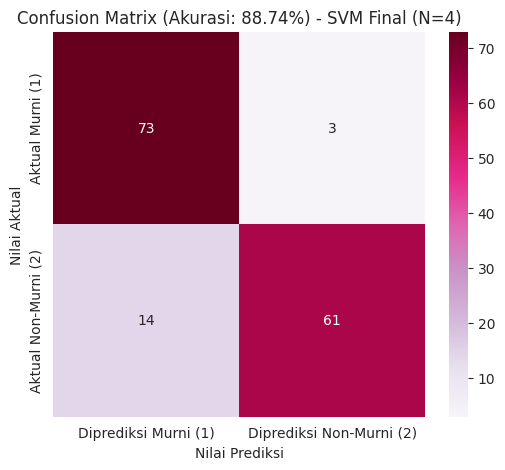

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

N_BEST_FEATURES = 4
best_features = ['Fitur_Time_180', 'Fitur_Time_183', 'Fitur_Time_57', 'Fitur_Time_58']

X_selected = X_resampled_adasyn[best_features]
y_selected = y_resampled_adasyn


# --- 3. STANDARISASI DAN PEMBAGIAN DATA ---

# Data train 80%, Data test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_selected, test_size=0.20, random_state=42, stratify=y_selected
)

# a. Imputasi NaN dilakukan pada data training/testing
imputer_model = SimpleImputer(strategy='mean')
X_train_imputed = imputer_model.fit_transform(X_train)
X_test_imputed = imputer_model.transform(X_test)

# b. Standarisasi (WAJIB untuk SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


# --- 4. PEMODELAN MENGGUNAKAN SUPPORT VECTOR MACHINE (SVC) ---

svm_model_final = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    probability=True # Penting untuk mendapatkan probabilitas di aplikasi Streamlit
)

# Latih Model SVM Final
svm_model_final.fit(X_train_scaled, y_train)


# --- 5. EVALUASI MODEL FINAL ---

y_pred = svm_model_final.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred) * 100
conf_matrix = confusion_matrix(y_test, y_pred)


print("\n" + "="*60)
print(f"--- Hasil Pemodelan SVM Final ({N_BEST_FEATURES} Fitur IG) ---")
print(f"Fitur Digunakan: {best_features}")
print(f"Akurasi Model pada Data Test (Data Seimbang): {accuracy:.2f}%")
print("="*60)
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['Kelas 1 (Murni)', 'Kelas 2 (Non-Murni)']))


# Visualisasi Evaluasi (Confusion Matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='PuRd',
    xticklabels=['Diprediksi Murni (1)', 'Diprediksi Non-Murni (2)'],
    yticklabels=['Aktual Murni (1)', 'Aktual Non-Murni (2)']
)
plt.title(f'Confusion Matrix (Akurasi: {accuracy:.2f}%) - SVM Final (N={N_BEST_FEATURES})')
plt.ylabel('Nilai Aktual')
plt.xlabel('Nilai Prediksi')
plt.savefig(f'confusion_matrix_svm_ig_{N_BEST_FEATURES}_final.png')



# --- 6. SIMPAN MODEL BARU UNTUK STREAMLIT ---
# Menggunakan nama file yang bersih untuk aplikasi produksi

MODEL_NAME = 'svm_ig_4features_final'

joblib.dump(scaler, f'scaler_{MODEL_NAME}.joblib')
joblib.dump(svm_model_final, f'model_{MODEL_NAME}.joblib')
joblib.dump(best_features, f'features_{MODEL_NAME}.joblib')
joblib.dump(imputer_model, f'imputer_{MODEL_NAME}.joblib')

print(f"\n[SUCCESS] Pipeline Model Final SVM ({N_BEST_FEATURES} Fitur) tersimpan.")
print(f"File model: model_{MODEL_NAME}.joblib, scaler_{MODEL_NAME}.joblib, features_{MODEL_NAME}.joblib, imputer_{MODEL_NAME}.joblib")

## Split data implementasi untuk ujicoba

In [ ]:
import pandas as pd
import os
import shutil
import joblib

# Nama file input
INPUT_FILENAME = "data_implementasi.csv"
# Nama folder sementara untuk menyimpan file split
TEMP_DIR = "split_implementation_data"
# Nama file ZIP output
OUTPUT_ZIP_FILENAME = "data_implementasi_split.zip"

try:
    # 1. Muat data implementasi
    df_implementasi = pd.read_csv(INPUT_FILENAME)

    # Periksa dan hapus folder sementara jika sudah ada
    if os.path.exists(TEMP_DIR):
        shutil.rmtree(TEMP_DIR)

    # Buat folder sementara baru
    os.makedirs(TEMP_DIR)

    # 2. Split dan Simpan Setiap Baris
    num_rows = len(df_implementasi)
    print(f"Mulai memproses {num_rows} sampel dari {INPUT_FILENAME}...")

    for index in range(num_rows):
        # Ambil satu baris data (pastikan tetap DataFrame dengan [index:index+1])
        row_df = df_implementasi.iloc[index:index+1]

        # Simpan sebagai file CSV terpisah
        output_path = os.path.join(TEMP_DIR, f"sample_{index+1}.csv")
        # index=False agar tidak menyimpan nomor indeks baris
        row_df.to_csv(output_path, index=False)

    print(f"Berhasil membuat {num_rows} file CSV di direktori '{TEMP_DIR}'.")

    # 3. Kompres Semua File ke ZIP
    # shutil.make_archive(nama_output_tanpa_ekstensi, format_kompresi, folder_sumber)
    shutil.make_archive(OUTPUT_ZIP_FILENAME.replace(".zip", ""), 'zip', TEMP_DIR)

    print(f"\n[SUCCESS] Semua file telah dikompresi menjadi '{OUTPUT_ZIP_FILENAME}'.")

except FileNotFoundError:
    print(f"\n[ERROR] File {INPUT_FILENAME} tidak ditemukan. Pastikan file telah diunggah atau namanya benar.")
except Exception as e:
    print(f"\n[ERROR] Terjadi kesalahan: {e}")

finally:
    # 4. Hapus folder sementara
    if os.path.exists(TEMP_DIR):
        shutil.rmtree(TEMP_DIR)
        print(f"Direktori sementara '{TEMP_DIR}' telah dihapus.")

Mulai memproses 248 sampel dari data_implementasi.csv...
Berhasil membuat 248 file CSV di direktori 'split_implementation_data'.

[SUCCESS] Semua file telah dikompresi menjadi 'data_implementasi_split.zip'.
Direktori sementara 'split_implementation_data' telah dihapus.


In [ ]:
import pandas as pd
import os
import shutil
import joblib

# Nama file input
INPUT_FILENAME = "data_implementasi.csv"
# Nama folder sementara untuk menyimpan file split
TEMP_DIR = "split_implementation_data_features_only" # Ganti nama folder
# Nama file ZIP output
OUTPUT_ZIP_FILENAME = "data_implementasi_split_features_only.zip" # Ganti nama file

try:
    # 1. Muat data implementasi
    df_implementasi = pd.read_csv(INPUT_FILENAME)

    # 2. Hapus kolom label (Asumsi kolom label bernama 'Class_Label')
    if 'Class_Label' in df_implementasi.columns:
        df_features_only = df_implementasi.drop(columns=['Class_Label'])
    else:
        # Jika 'Class_Label' tidak ditemukan, asumsikan kolom pertama adalah label
        # dan kolom lainnya adalah fitur (seperti yang dilakukan pada langkah sebelumnya).
        # Namun, di sini kita hanya akan mengambil semua kolom yang ada,
        # karena di tahap ini seharusnya hanya fitur yang tersisa.
        df_features_only = df_implementasi.copy()
        print("[WARNING] Kolom 'Class_Label' tidak ditemukan. Diasumsikan file hanya berisi fitur.")


    # --- Persiapan Direktori ---
    if os.path.exists(TEMP_DIR):
        shutil.rmtree(TEMP_DIR)

    os.makedirs(TEMP_DIR)

    # 3. Split dan Simpan Setiap Baris
    num_rows = len(df_features_only)
    print(f"Mulai memproses {num_rows} sampel (hanya fitur) dari {INPUT_FILENAME}...")

    for index in range(num_rows):
        # Ambil satu baris data dari DataFrame fitur-saja
        row_df = df_features_only.iloc[index:index+1]

        # Simpan sebagai file CSV terpisah
        output_path = os.path.join(TEMP_DIR, f"sample_feature_{index+1}.csv")
        # index=False agar tidak menyimpan nomor indeks baris
        row_df.to_csv(output_path, index=False)

    print(f"Berhasil membuat {num_rows} file CSV (hanya fitur) di direktori '{TEMP_DIR}'.")

    # 4. Kompres Semua File ke ZIP
    shutil.make_archive(OUTPUT_ZIP_FILENAME.replace(".zip", ""), 'zip', TEMP_DIR)

    print(f"\n[SUCCESS] Semua file telah dikompresi menjadi '{OUTPUT_ZIP_FILENAME}'.")

except FileNotFoundError:
    print(f"\n[ERROR] File {INPUT_FILENAME} tidak ditemukan. Pastikan file telah diunggah atau namanya benar.")
except Exception as e:
    print(f"\n[ERROR] Terjadi kesalahan: {e}")

finally:
    # 5. Hapus folder sementara
    if os.path.exists(TEMP_DIR):
        shutil.rmtree(TEMP_DIR)
        print(f"Direktori sementara '{TEMP_DIR}' telah dihapus.")

Mulai memproses 248 sampel (hanya fitur) dari data_implementasi.csv...
Berhasil membuat 248 file CSV (hanya fitur) di direktori 'split_implementation_data_features_only'.

[SUCCESS] Semua file telah dikompresi menjadi 'data_implementasi_split_features_only.zip'.
Direktori sementara 'split_implementation_data_features_only' telah dihapus.


## Deployment

dari hasil yang dicapai tecipta aplikasi https://prediksistrawberi.streamlit.app/ menggunakan SVM dengan 4 fitur link webstatis https://dhyos.github.io/PSD/UAS_Project.html Ambil Data Ujicoba https://github.com/dhyos/prediksistrawberi dan lihat data https://github.com/dhyos/prediksistrawberi/tree/main/data_implementasi_split_features_only link dataset https://www.timeseriesclassification.com/description.php?Dataset=Strawberry referensi jurnal https://sci-hub.se/10.1002/(SICI)1097-0010(199802)76:2%3C263::AID-JSFA943%3E3.0.CO;2-Fd
